# Polypharmacy Graphs

Steps:
1. Raw Tables
2. Clusters
3. Predictive Signal

**Goal:** Turn the polypharmacy side effect table into useful graphs, make the structure visible (clusters, hubs), and show it’s predictive (AUC ~ 0.9).


- Build two views: drug–drug “interaction”, drug–effect bipartite.
- Project to drug–drug similarity using Jaccard (interpretable) and TF-IDF (Term Frequency-Inverse Document Frequency) cosine.
- Sparse threshold + top-k so clusters/hubs appear.
- Evaluate bipartite aware link prediction: AUC.

**Why graphs?**
Side effect overlap is a phenotypic fingerprint, similar fingerprints often imply shared biology / risks.


In [ ]:
import os, re, random, math
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity, roc_auc_score
import scipy.sparse as sp

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
plt.rcParams["figure.dpi"] = 160

DATA_DIR  = Path(".").resolve()           # change to Path("/path/to/your/folder") if needed
FILE_NAME = "ChChSe-Decagon_polypharmacy.csv"
PATH      = (DATA_DIR / FILE_NAME)

# Validate input
if not PATH.exists():
    raise FileNotFoundError(
        f"Could not find '{FILE_NAME}' in:\n  {DATA_DIR}\n"
        "Place the CSV next to the notebook or set DATA_DIR = Path('/path/to/folder')."
    )

OUT_DIR = DATA_DIR / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PAIR_DF_CSV       = OUT_DIR / "pair_df.csv"
BIP_DF_CSV        = OUT_DIR / "bip_df.csv"
FIG_HOT           = OUT_DIR / "fig_hot_pairs.png"
FIG_JACC          = OUT_DIR / "fig_projection_jaccard.png"
FIG_COS           = OUT_DIR / "fig_projection_cosine.png"
FIG_COS_BACKBONE  = OUT_DIR / "fig_cosine_backbone.png"

print("Input file:", PATH.name)
print("Saving outputs to:", OUT_DIR)

# Effect frequency filter (keep mid-frequency effects)
MIN_EFF_DRUGS = 10          # drop ultra rare effects
MAX_EFF_FRACT = 0.60        # drop effects present in >60% of drugs

# Backbone sparsification
JACCARD_THRESH = 0.15
JACCARD_TOPK   = 10
COSINE_THRESH  = 0.32
COSINE_TOPK    = 6


print("Reading CSV with pandas (comma; falls back to tab if needed)...")
try:
    raw = pd.read_csv(PATH, dtype=str, low_memory=False)
except Exception:
    raw = pd.read_csv(PATH, sep="\t", dtype=str, low_memory=False)

# If the rest of notebook expects `df` right away:
df = raw.copy()


Mounted at /content/drive


In [ ]:
def read_polypharm(path: str) -> pd.DataFrame:
    """CSV reader: handles comma/tab and messy headers."""
    try:
        df = pd.read_csv(path, dtype=str, low_memory=False)
    except Exception:
        df = pd.read_csv(path, sep="\t", dtype=str, low_memory=False)

    def _norm(s: str) -> str:
        s = (s or "").replace("\ufeff","").strip()
        s = re.sub(r"\s+", " ", s)
        return s

    df.columns = [_norm(c) for c in df.columns]

    # Find required columns by regex (handles header variants)
    def find_col(pat):
        rx = re.compile(pat, flags=re.I)
        for c in df.columns:
            if rx.search(c): return c
        return None

    col_st1 = find_col(r"(#\s*)?stitch\s*1\b")
    col_st2 = find_col(r"(#\s*)?stitch\s*2\b")
    col_se  = find_col(r"side\s*effect\s*name")

    if not all([col_st1, col_st2, col_se]):
        raise RuntimeError(
            "Required columns not found. "
            f"Detected STITCH1={col_st1}, STITCH2={col_st2}, SE_NAME={col_se}.\n"
            f"Columns available: {df.columns.tolist()}"
        )

    df = df[[col_st1, col_st2, col_se]].dropna()
    df = df.rename(columns={col_st1:"# STITCH 1", col_st2:"# STITCH 2", col_se:"Side Effect Name"})
    return df

print("Reading:", PATH)
raw = read_polypharm(PATH)
print("Raw rows:", len(raw))

# Normalize values (order drug IDs: clean effect text)
df = raw.copy()
df["drug_a"] = df[["# STITCH 1","# STITCH 2"]].min(axis=1)
df["drug_b"] = df[["# STITCH 1","# STITCH 2"]].max(axis=1)
df["effect"] = df["Side Effect Name"].str.strip().str.lower()


Reading: /content/drive/MyDrive/chem274b_final/sample_data/ChChSe-Decagon_polypharmacy.csv
Raw rows: 4649441


In [ ]:
# Aggregate to tidy tables
# One row per (drug_a, drug_b) with unique effects and count

pair_df = (df.groupby(["drug_a","drug_b"])["effect"]
             .agg(lambda s: sorted(set(s))).reset_index())
pair_df["n_effects"] = pair_df["effect"].str.len()
pair_df.to_csv(PAIR_DF_CSV, index=False)

# B) One row per (drug, effect) for bipartite
bip_df = (pd.concat([
            df[["# STITCH 1","effect"]].rename(columns={"# STITCH 1":"drug"}),
            df[["# STITCH 2","effect"]].rename(columns={"# STITCH 2":"drug"})
          ], ignore_index=True)
          .drop_duplicates())
bip_df.to_csv(BIP_DF_CSV, index=False)

print("pair_df:", pair_df.shape, "->", PAIR_DF_CSV)
print("bip_df :", bip_df.shape,  "->", BIP_DF_CSV)


pair_df: (63473, 4) -> /content/drive/MyDrive/chem274b_final/sample_data/pair_df.csv
bip_df : (341773, 2) -> /content/drive/MyDrive/chem274b_final/sample_data/bip_df.csv


In [ ]:
# Building graphs
# Interaction graph (drug–drug), edge attribute: n_effects + full effect list
G = nx.Graph()
for r in pair_df.itertuples(index=False):
    G.add_edge(r.drug_a, r.drug_b, n_effects=r.n_effects, effects=r.effect)

# Bipartite graph (drug–effect)
B = nx.Graph()
B.add_nodes_from(bip_df["drug"].unique(),   kind="drug",   bipartite=0)
B.add_nodes_from(bip_df["effect"].unique(), kind="effect", bipartite=1)
B.add_edges_from(bip_df.itertuples(index=False, name=None))

print(f"Interaction G: |V|={G.number_of_nodes()} |E|={G.number_of_edges()}")
print(f"Bipartite   B: |V|={B.number_of_nodes()} |E|={B.number_of_edges()}")


Interaction G: |V|=645 |E|=63473
Bipartite   B: |V|=1962 |E|=341773


## Why filtering & TF-IDF (Term Frequency-Inverse Document Frequency) help

1. Edges sized by number of unique side-effects: shows “busy” pairs.  
2. Even after degree filtering, Jaccard is very dense, necessary to reduce noise

These two figures explain why we filter effects and switch to TF IDF cosine.


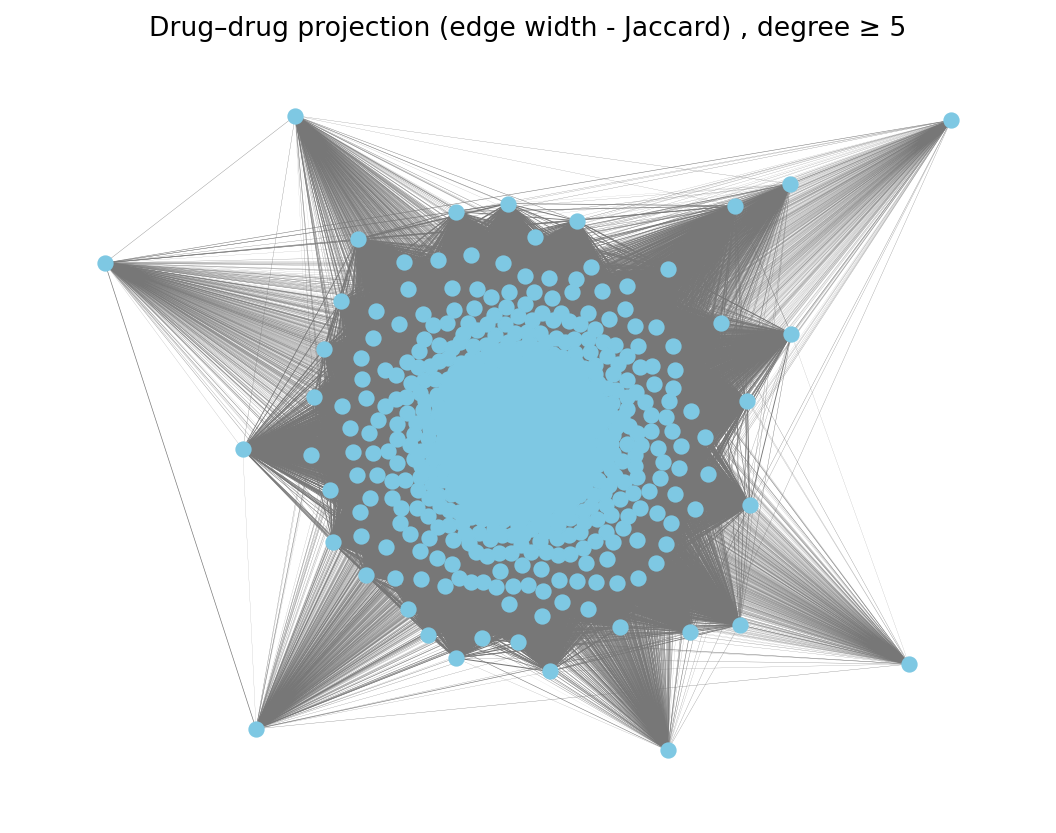

Saved: /content/drive/MyDrive/chem274b_final/sample_data/fig_projection_jaccard.png


In [ ]:
# Jaccard projection - Naïve projection is almost complete due to ubiquitous effects
drugs = [n for n,d in B.nodes(data=True) if d["kind"]=="drug"]

P_j_dense = nx.bipartite.weighted_projected_graph(B, drugs)  # weight = shared count

nbrs = {u:set(B.neighbors(u)) for u in drugs}

for u,v in P_j_dense.edges():
    inter = len(nbrs[u] & nbrs[v])
    uni = len(nbrs[u] | nbrs[v])
    P_j_dense[u][v]["jaccard"] = inter/uni if uni else 0.0

# Degree filter just to draw something readable
deg = dict(P_j_dense.degree())
keep = {n for n,c in deg.items() if c >= 5} or set(P_j_dense.nodes())
S = P_j_dense.subgraph(keep).copy()

pos = nx.spring_layout(S, seed=SEED)
ew  = [S[u][v]["jaccard"]*3 for u,v in S.edges()]

nx.draw(S, pos, node_size=40, width=ew, node_color="#7ec8e3", edge_color="#777")
plt.title("Drug–drug projection (edge width - Jaccard) , degree ≥ 5")
plt.gcf().subplots_adjust(left=0.02, right=0.98, top=0.92, bottom=0.02)
plt.savefig(FIG_JACC)
plt.show()
print("Saved:", FIG_JACC)


In [ ]:
# Effect filter and two projections
# Filter effects to mid frequency
n_drugs = bip_df["drug"].nunique()
eff_counts = bip_df["effect"].value_counts()
keep_effects = eff_counts[(eff_counts >= MIN_EFF_DRUGS) & (eff_counts <= MAX_EFF_FRACT*n_drugs)].index
bip_df_f = bip_df[bip_df["effect"].isin(keep_effects)].copy()
print("After filtering:", bip_df_f["effect"].nunique(), "effects- edges:", len(bip_df_f))

# Rebuild filtered bipartite
B_f = nx.Graph()
B_f.add_nodes_from(bip_df_f["drug"].unique(),   kind="drug",   bipartite=0)
B_f.add_nodes_from(bip_df_f["effect"].unique(), kind="effect", bipartite=1)
B_f.add_edges_from(bip_df_f.itertuples(index=False, name=None))

drugs_f   = [n for n,d in B_f.nodes(data=True) if d["kind"]=="drug"]
effects_f = [n for n,d in B_f.nodes(data=True) if d["kind"]=="effect"]
print(f"B_f: |V|={B_f.number_of_nodes()} |E|={B_f.number_of_edges()}")

# Jaccard projection on filtered bipartite
P_j = nx.bipartite.weighted_projected_graph(B_f, drugs_f)
nbrs_f = {u:set(B_f.neighbors(u)) for u in drugs_f}
for u,v in P_j.edges():
    inter = len(nbrs_f[u] & nbrs_f[v])
    uni = len(nbrs_f[u] | nbrs_f[v])
    P_j[u][v]["jaccard"] = inter/uni if uni else 0.0

# TF-IDF cosine projection (main)
drugs_list = sorted(drugs_f)
effects_list = sorted(effects_f)
di = {n:i for i,n in enumerate(drugs_list)}
ei = {n:i for i,n in enumerate(effects_list)}

X = sp.lil_matrix((len(drugs_list), len(effects_list)))
for u,v in B_f.edges():
    if B_f.nodes[u]["kind"]=="drug": X[di[u], ei[v]] = 1
    else:                            X[di[v], ei[u]] = 1

tfidf = TfidfTransformer().fit_transform(X)
C = cosine_similarity(tfidf)  # (n_drugs x n_drugs)

P_c = nx.Graph()
TOPK_COS_BUILD = 25  # build a moderately sparse cosine graph first
for i,u in enumerate(drugs_list):
    row = C[i]
    idx = np.argsort(row)[::-1][1:TOPK_COS_BUILD+1]  # skip self
    for j in idx:
        v = drugs_list[j]
        w = float(row[j])
        if w > 0:
            if P_c.has_edge(u,v):
                P_c[u][v]["cosine"] = max(P_c[u][v]["cosine"], w)
            else:
                P_c.add_edge(u,v, cosine=w)

print("P_j:", P_j.number_of_nodes(), "nodes,", P_j.number_of_edges(), "edges")
print("P_c:", P_c.number_of_nodes(), "nodes,", P_c.number_of_edges(), "edges")


After filtering: 978 effects- edges: 184255
B_f: |V|=1622 |E|=184255
P_j: 644 nodes, 202762 edges
P_c: 644 nodes, 15452 edges


In [ ]:
def backbone(P: nx.Graph, weight_key: str, thresh: float, topk: int) -> nx.Graph:
    """Keep edges above similarity threshold and the top-k strongest per node."""
    keep = set()
    # threshold
    for u,v,d in P.edges(data=True):
        if d.get(weight_key, 0.0) >= thresh:
            keep.add(tuple(sorted((u,v))))
    # top-k per node
    for u in P.nodes():
        nbrs = sorted(P[u].items(), key=lambda kv: kv[1].get(weight_key,0), reverse=True)[:topk]
        for v,_ in nbrs:
            keep.add(tuple(sorted((u,v))))
    return P.edge_subgraph(keep).copy()

def draw_weighted(G, weight_key, title, path=None, pos=None, node_color=None):
    if G.number_of_edges()==0:
        print("Empty graph:", title)
        return
    pos = pos or nx.spring_layout(G, seed=SEED)
    widths = [G[u][v].get(weight_key,0)*4 for u,v in G.edges()]
    nx.draw(G, pos, node_size=26, width=widths, node_color=node_color or "#7ec8e3",
            cmap="tab10", edge_color="#9aa0a6", alpha=0.9)
    plt.title(title)
    plt.gcf().subplots_adjust(left=0.02, right=0.98, top=0.93, bottom=0.02)
    if path: plt.savefig(path, dpi=300)
    plt.show()


/usr/local/lib/python3.12/dist-packages/networkx/drawing/nx_pylab.py:1495: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  node_collection = ax.scatter(


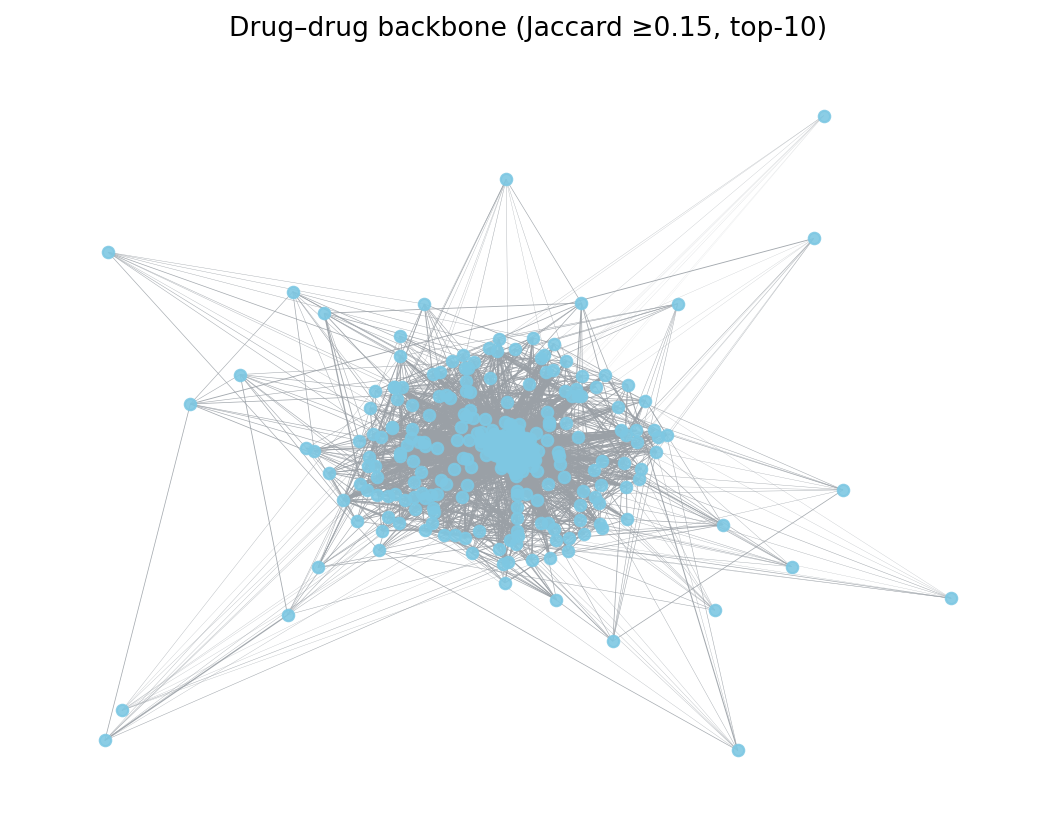

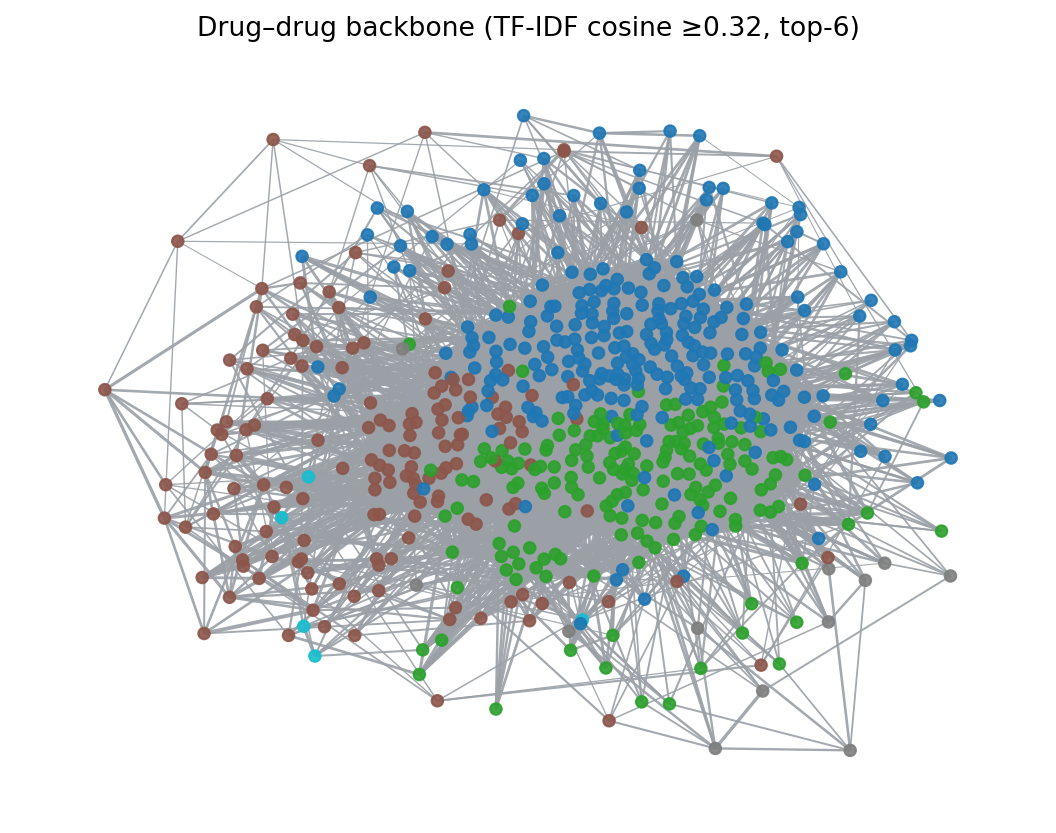

Community sizes (largest first): [277, 188, 161, 13, 5]


In [ ]:
# Jaccard backbone
S_j = backbone(P_j, "jaccard", JACCARD_THRESH, JACCARD_TOPK)
draw_weighted(S_j, "jaccard",
              f"Drug–drug backbone (Jaccard ≥{JACCARD_THRESH}, top-{JACCARD_TOPK})",
              FIG_JACC)

# Cosine backbone
S_c = backbone(P_c, "cosine", COSINE_THRESH, COSINE_TOPK)

from networkx.algorithms.community import greedy_modularity_communities
comms = greedy_modularity_communities(S_c, weight="cosine")
comm_id = {n:i for i,c in enumerate(comms) for n in c}
colors = [comm_id[n] for n in S_c.nodes()]
pos_c = nx.spring_layout(S_c, seed=SEED)

draw_weighted(S_c, "cosine",
              f"Drug–drug backbone (TF-IDF cosine ≥{COSINE_THRESH}, top-{COSINE_TOPK})",
              FIG_COS_BACKBONE, pos=pos_c, node_color=colors)

print("Community sizes (largest first):", sorted([len(c) for c in comms], reverse=True)[:6])


In [ ]:
# Displaying hubs
deg = dict(S_c.degree())
top_hubs = sorted(deg.items(), key=lambda kv: kv[1], reverse=True)[:10]
pd.DataFrame(top_hubs, columns=["drug_id","backbone_degree"]).to_csv(
    f"{PATH_DIR}/top_hubs.csv", index=False)
print("Top hubs:", top_hubs[:5])

# Effects per drug (lookup)
drug_to_effects = {}
for u,v in B_f.edges():
    if B_f.nodes[u]["kind"]=="drug": drug_to_effects.setdefault(u,set()).add(v)
    else:                            drug_to_effects.setdefault(v,set()).add(u)

# top effects per community
rows = []
for i,c in enumerate(comms):
    eff_freq = {}
    for d in c:
        for e in drug_to_effects.get(d, []):
            eff_freq[e] = eff_freq.get(e, 0) + 1
    top5 = sorted(eff_freq.items(), key=lambda kv: kv[1], reverse=True)[:5]
    rows.append({"community": i, "size": len(c),
                 "top_effects": ", ".join([f"{e} ({cnt})" for e,cnt in top5])})

comm_df = pd.DataFrame(rows).sort_values("size", ascending=False)
comm_df.to_csv(f"{PATH_DIR}/community_summary.csv", index=False)
comm_df.head(6)

# Nearest neighbors for a hub
def nearest_neighbors(drug, S=S_c, k=12):
    if drug not in S:
        return pd.DataFrame(columns=["neighbor","similarity"])
    nbrs = [(v, S[drug][v]["cosine"]) for v in S[drug]]
    return (pd.DataFrame(sorted(nbrs, key=lambda x: x[1], reverse=True)[:k],
                         columns=["neighbor","similarity"]))

zoom_id = top_hubs[0][0]
nn = nearest_neighbors(zoom_id, k=12)
nn.to_csv(f"{PATH_DIR}/nearest_neighbors.csv", index=False)
nn.head(12)


Top hubs: [('CID000005391', 177), ('CID000002249', 166), ('CID000004889', 152), ('CID000005732', 152), ('CID000004510', 149)]


,neighbor,similarity
0,CID000003386,0.754362
1,CID000003639,0.750649
2,CID000002249,0.746715
3,CID000004253,0.737149
4,CID000003345,0.735414
5,CID000004691,0.733756
6,CID000003883,0.733620
7,CID000004635,0.733310
8,CID000002802,0.730734
9,CID000005656,0.729067


## AUC: Does the structure generalize?

For a candidate (drug d, effect e), we score it by how similar d is to the drugs already linked to e in the training graph:

$\text{score}(d,e) = \sum_{d' \in N_{\text{train}}(e)} \text{sim}(d, d')$


- With Jaccard or cosine as the drug–drug similarity, AUC measures the probability a true edge outranks a random non edge.  
- AUC ≈ **0.90** indicates strong predictive signal


In [ ]:
# Bipartite link prediction AUC
def build_sim(S: nx.Graph, key: str):
    sim = {}
    for u,v,d in S.edges(data=True):
        w = d.get(key,0.0)
        sim.setdefault(u, {})[v] = w
        sim.setdefault(v, {})[u] = w
    return sim

def bipartite_auc(B_eval: nx.Graph, S_sim: nx.Graph, key: str, test_frac=0.10) -> float:
    sim = build_sim(S_sim, key)
    pos = list(B_eval.edges())
    random.shuffle(pos)
    n_test = max(1000, int(test_frac*len(pos)))
    test_pos = pos[:n_test]

    # Train graph
    B_train = B_eval.copy()
    B_train.remove_edges_from(test_pos)

    def ensure_drug_effect(u,v):
        return (u,v) if B_eval.nodes[u]["kind"]=="drug" else (v,u)

    def score(d,e):
        neigh = [x for x in B_train.neighbors(e) if B_train.nodes[x]["kind"]=="drug"]
        return sum(sim.get(d, {}).get(dp, 0.0) for dp in neigh)

    tp = [ensure_drug_effect(u,v) for u,v in test_pos]

    # random drug effect non dedges
    drugs  = [n for n in B_eval.nodes() if B_eval.nodes[n]["kind"]=="drug"]
    effects= [n for n in B_eval.nodes() if B_eval.nodes[n]["kind"]=="effect"]
    neg=[]
    while len(neg)<len(tp):
        d = random.choice(drugs)
        e = random.choice(effects)
        if not B_eval.has_edge(d,e): neg.append((d,e))

    pos_scores = [score(d,e) for d,e in tp]
    neg_scores = [score(d,e) for d,e in neg]
    return roc_auc_score([1]*len(tp)+[0]*len(neg), pos_scores+neg_scores)

auc_jacc = bipartite_auc(B_f, S_j, "jaccard")
auc_cos  = bipartite_auc(B_f, S_c, "cosine")
print(f"AUC — Jaccard: {auc_jacc:.3f} | Cosine: {auc_cos:.3f}")


AUC — Jaccard: 0.894 | Cosine: 0.908


In [ ]:
# Recompute and display "top effects per community"
from IPython.display import display
import pandas as pd

# building effects per drug lookup from the filtered bipartite graph
drug_to_effects = {}
for u, v in B_f.edges():
    if B_f.nodes[u]["kind"] == "drug":
        drug_to_effects.setdefault(u, set()).add(v)
    else:
        drug_to_effects.setdefault(v, set()).add(u)

# summarize each community by its most frequent effects
rows = []
for i, comm in enumerate(comms):                 # comm is a set of drug IDs (from S_c communities)
    eff_freq = {}
    for d in comm:
        for eff in drug_to_effects.get(d, []):   # effects linked to drug d in B_f
            eff_freq[eff] = eff_freq.get(eff, 0) + 1
    # top 5 effects by coverage within this community
    top5 = sorted(eff_freq.items(), key=lambda kv: kv[1], reverse=True)[:5]
    rows.append({
        "community": i,
        "size": len(comm),
        "top_effects": ", ".join([f"{eff} ({cnt})" for eff, cnt in top5])
    })

comm_df = pd.DataFrame(rows).sort_values("size", ascending=False)
display(comm_df.head(8))
# Save for slides
comm_df.to_csv(f"{PATH_DIR}/community_summary.csv", index=False)
print("Saved:", f"{PATH_DIR}/community_summary.csv")


,community,size,top_effects
0,0,277,"glaucoma (193), hip fracture (189), excessive ..."
1,1,188,"abortion spontaneous (161), paranoia (159), ph..."
2,2,161,"cmv infection (88), hepatic necrosis (86), hae..."
3,3,13,"ventricular septal defect (7), patent ductus a..."
4,4,5,"psoriasis (4), penile swelling (3), hepatitis ..."


Saved: /content/drive/MyDrive/chem274b_final/sample_data/community_summary.csv
